<a href="https://colab.research.google.com/github/Bavesh-08/house-price-prediction/blob/main/House_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing the dependencies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:
#loading the dataset

housing=pd.read_csv('/content/House Price Prediction Dataset.csv')
print(housing)

        Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0        1  1360         5          4       3       1970  Downtown  Excellent   
1        2  4272         5          4       3       1958  Downtown  Excellent   
2        3  3592         2          2       3       1938  Downtown       Good   
3        4   966         4          2       2       1902  Suburban       Fair   
4        5  4926         1          4       2       1975  Downtown       Fair   
...    ...   ...       ...        ...     ...        ...       ...        ...   
1995  1996  4994         5          4       3       1923  Suburban       Poor   
1996  1997  3046         5          2       1       2019  Suburban       Poor   
1997  1998  1062         5          1       2       1903     Rural       Poor   
1998  1999  4062         3          1       2       1936     Urban  Excellent   
1999  2000  2989         5          1       3       1903  Suburban       Fair   

     Garage   Price  
0    

In [ ]:
#loading all the data to panda dataframe

housing_data=pd.DataFrame(housing)
print(housing_data)


        Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0        1  1360         5          4       3       1970  Downtown  Excellent   
1        2  4272         5          4       3       1958  Downtown  Excellent   
2        3  3592         2          2       3       1938  Downtown       Good   
3        4   966         4          2       2       1902  Suburban       Fair   
4        5  4926         1          4       2       1975  Downtown       Fair   
...    ...   ...       ...        ...     ...        ...       ...        ...   
1995  1996  4994         5          4       3       1923  Suburban       Poor   
1996  1997  3046         5          2       1       2019  Suburban       Poor   
1997  1998  1062         5          1       2       1903     Rural       Poor   
1998  1999  4062         3          1       2       1936     Urban  Excellent   
1999  2000  2989         5          1       3       1903  Suburban       Fair   

     Garage   Price  
0    

In [ ]:
#to see the top five rows in the dataset

housing_data.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
#checking the number of rows

housing_data.shape

(2000, 10)

In [ ]:
#to check our data have any missing value

housing_data.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [ ]:
#finding the count of different labels

housing_data[['Garage', 'Condition', 'Location']].value_counts()

Garage  Condition  Location
No      Excellent  Downtown    85
        Fair       Downtown    82
Yes     Fair       Rural       77
No      Good       Downtown    76
        Poor       Urban       72
        Excellent  Rural       70
Yes     Excellent  Downtown    68
No      Excellent  Suburban    68
                   Urban       67
Yes     Fair       Suburban    66
        Poor       Downtown    66
No      Poor       Downtown    66
        Fair       Urban       63
Yes     Poor       Suburban    63
        Fair       Urban       62
No      Fair       Suburban    61
Yes     Poor       Rural       61
No      Poor       Rural       61
Yes     Good       Suburban    61
                   Downtown    60
No      Poor       Suburban    60
Yes     Good       Urban       60
        Poor       Urban       58
No      Fair       Rural       55
Yes     Fair       Downtown    55
        Excellent  Suburban    54
No      Good       Urban       54
Yes     Good       Rural       52
        Excellent  Rural       50
No      Good       Suburban    50
Yes     Excellent  Urban       49
No      Good       Rural       48
Name: count, dtype: int64

In [ ]:
label=LabelEncoder()
housing_data['Garage']=label.fit_transform(housing_data['Garage'])
housing_data['Condition']=label.fit_transform(housing_data['Condition'])
housing_data['Location']=label.fit_transform(housing_data['Location'])

In [ ]:
#to get the statitical data of the dataset

housing_data.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,1.447500,1.482000,0.481000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,1.136173,1.126193,0.499764,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,0.000000,0.000000,0.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,0.000000,0.000000,0.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,1.000000,1.000000,0.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,2.000000,3.000000,1.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,3.000000,3.000000,1.000000,999656.000000


In [ ]:
#spliting the data and target

x=housing_data.drop(['Price'],axis=1)
y=housing_data['Price']
print(x)



        Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0        1  1360         5          4       3       1970  Downtown  Excellent   
1        2  4272         5          4       3       1958  Downtown  Excellent   
2        3  3592         2          2       3       1938  Downtown       Good   
3        4   966         4          2       2       1902  Suburban       Fair   
4        5  4926         1          4       2       1975  Downtown       Fair   
...    ...   ...       ...        ...     ...        ...       ...        ...   
1995  1996  4994         5          4       3       1923  Suburban       Poor   
1996  1997  3046         5          2       1       2019  Suburban       Poor   
1997  1998  1062         5          1       2       1903     Rural       Poor   
1998  1999  4062         3          1       2       1936     Urban  Excellent   
1999  2000  2989         5          1       3       1903  Suburban       Fair   

     Garage  
0        No  

In [ ]:
# standardising the data

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x = housing_data.drop(['Price'], axis=1)

x = x.values
x = scaler.fit_transform(x)
print(x.std())

1.0


In [ ]:
#spliting the data into traning data and test data

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)
print(x_train.shape,x_test.shape)


(1600, 9) (400, 9)


In [ ]:
#model traning

model=LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
#predtiting the traning data

training_data_prediction=model.predict(x_train)
print(training_data_prediction)

[527028.33015162 538215.66116019 527302.99755825 ... 523147.54314726
 529787.72548156 531995.4705953 ]


In [ ]:
#squarred error

score_1=metrics.r2_score(y_train,training_data_prediction)

#mean absolute error

score_2=metrics.mean_absolute_error(y_train,training_data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)




R squared error :  0.00677993001821231
Mean Absolute Error :  237632.1143720685


In [ ]:
# Predicting on the test data
test_data_prediction = model.predict(x_test)


In [ ]:
# R squared error for test data
score_3 = metrics.r2_score(y_test, test_data_prediction)

# Mean absolute error for test data
score_4 = metrics.mean_absolute_error(y_test, test_data_prediction)

print("R squared error (Test Data) : ", score_3)
print('Mean Absolute Error (Test Data) : ', score_4)

R squared error (Test Data) :  -0.015589455960564491
Mean Absolute Error (Test Data) :  243259.44707596983


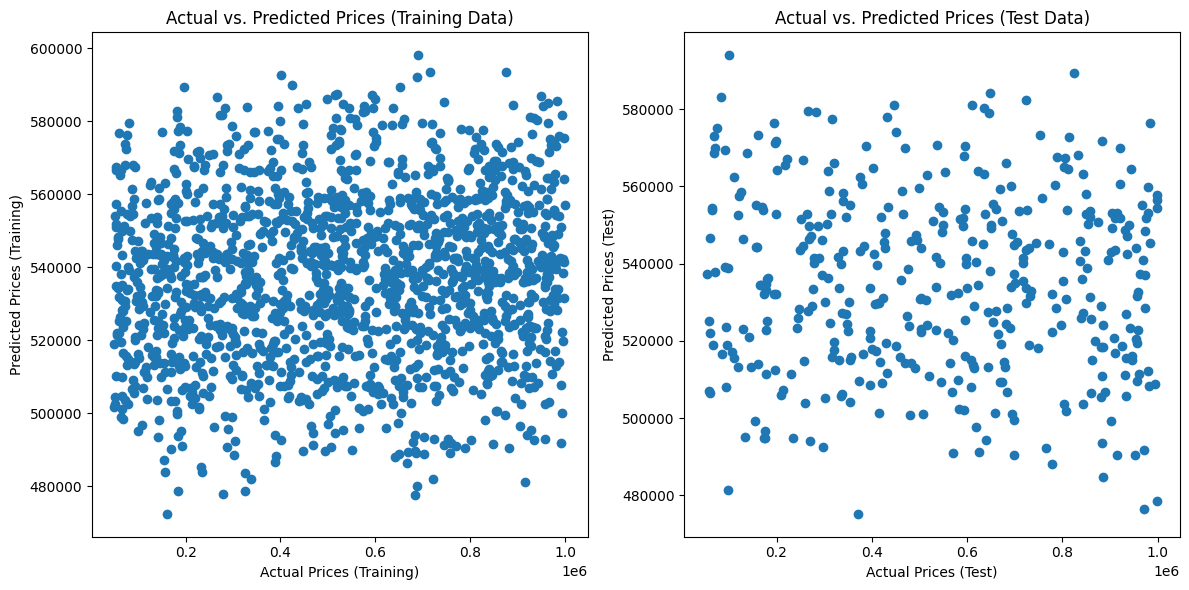

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_train, training_data_prediction)
plt.xlabel("Actual Prices (Training)")
plt.ylabel("Predicted Prices (Training)")
plt.title("Actual vs. Predicted Prices (Training Data)")

plt.subplot(1, 2, 2)
plt.scatter(y_test, test_data_prediction)
plt.xlabel("Actual Prices (Test)")
plt.ylabel("Predicted Prices (Test)")
plt.title("Actual vs. Predicted Prices (Test Data)")

plt.tight_layout()
plt.show()